In [73]:
import requests
import re
from bs4 import BeautifulSoup

def parse_eng():
    url = "https://www.gutenberg.org/files/2554/2554-h/2554-h.htm"

    response = requests.get(url)
    response.encoding = 'utf-8'
    html_content = response.text

    soup = BeautifulSoup(html_content, 'html.parser')

    chapters = soup.find_all('div', class_='chapter')


    result_lines = []

    for chapter_div in chapters:
        title_tag = chapter_div.find('h2')
        if title_tag:
            title_text = title_tag.get_text(strip=True)
            if re.match(r'^PART\s+', title_text, re.IGNORECASE):
                result_lines.append(title_text.upper())
                continue

        if title_tag and re.match(r'^CHAPTER\s+\w+', title_text, re.IGNORECASE):
            result_lines.append(title_text)

        for a in chapter_div.find_all('a'):
            a.unwrap()

        text = chapter_div.get_text(separator='\n', strip=True)

        if title_tag:
            title_clean = title_tag.get_text(strip=True)
            lines = text.split('\n')
            if lines and lines[0].strip() == title_clean:
                text = '\n'.join(lines[1:])

        if text.strip():
            result_lines.append(text)
            result_lines.append("")


    epilog = soup.find('div', id='link2H_EPIL')
    if epilog:
        result_lines.append("")
        result_lines.append("=" * 80)
        result_lines.append("EPILOGUE")
        result_lines.append("=" * 80)
        result_lines.append("")

        epilog_text = epilog.get_text(separator='\n', strip=True)
        for a in epilog.find_all('a'):
            a.unwrap()

        for h3 in epilog.find_all('h3'):
            if h3.get_text(strip=True) in ['I', 'II']:
                result_lines.append("")
                result_lines.append("-" * 40)
                result_lines.append(f"Part {h3.get_text(strip=True)}")
                result_lines.append("-" * 40)
                result_lines.append("")

        for p in epilog.find_all('p'):
            p_text = p.get_text(strip=True)
            if p_text:
                result_lines.append(p_text)

    output_file = 'crime_and_punishment_eng.txt'
    with open(output_file, 'w', encoding='utf-8') as f:
        f.write('\n'.join(result_lines))
    return output_file

parse_eng()

'crime_and_punishment_eng.txt'

In [74]:
def parse_rus():
    url = "https://lib.pravmir.ru/library/readbook/1931"
    response = requests.get(url)
    response.encoding = 'utf-8'
    html_content = response.text

    soup = BeautifulSoup(html_content, 'html.parser')

    content_div = soup.find('div', class_='book_read', id='selectable-content')


    parts = content_div.find_all('div', id=re.compile(r'^part_\d+'))


    result_lines = []

    for part in parts:
        title_tag = part.find('h2')
        if title_tag:
            title_text = title_tag.get_text(strip=True)
            title_text = re.sub(r'\s*\d+\s*', '', title_text).strip()
            if title_text:
                result_lines.append(title_text.upper())


        for elem in part.find_all(['p', 'div']):
            if elem.name == 'p':
                text = elem.get_text()
                text = re.sub(r'\s*\d+\s*', '', text)
                text = re.sub(r'\n\s*\n', '\n', text)
                text = text.strip()

                if text:
                    result_lines.append(text)
                    result_lines.append("")
            else:
                text = elem.get_text()
                text = re.sub(r'\s*\d+\s*', '', text)
                text = re.sub(r'\n\s*\n', '\n', text)
                text = text.strip()
                if text and len(text) > 10:
                    result_lines.append(text)
                    result_lines.append("")

    output_file = 'crime_and_punishment_rus.txt'
    with open(output_file, 'w', encoding='utf-8') as f:
        f.write('\n'.join(result_lines))

parse_rus()

In [75]:
!pip install pymorphy3


In [76]:
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import pymorphy3

try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')
try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')

plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")

def load_texts():
    with open('crime_and_punishment_rus.txt', 'r', encoding='utf-8') as f:
        russian_text = f.read()
    with open('crime_and_punishment_eng.txt', 'r', encoding='utf-8') as f:
        english_text = f.read()
    return russian_text, english_text

def split_chapters(text, language='ru'):
    parts = re.split(r'={80,}', text)
    fragments = []
    for part in parts:
        if len(part) > 500:
            chunk_size = 2000
            for i in range(0, len(part), chunk_size):
                chunk = part[i:i+chunk_size]
                if len(chunk) > 200:
                    fragments.append(chunk[:2000])
    return fragments[:30]

wordnet_lemmatizer = WordNetLemmatizer()
morph = pymorphy3.MorphAnalyzer()

def lemmatize_english_text(text):
    tokens = nltk.word_tokenize(text)
    lemmas = [wordnet_lemmatizer.lemmatize(token) for token in tokens]
    return ' '.join(lemmas)

def lemmatize_russian_text(text):
    tokens = re.findall(r'[а-яё]+', text.lower())
    lemmas = [morph.parse(token)[0].normal_form for token in tokens]
    return ' '.join(lemmas)

russian_text, english_text = load_texts()
english_stopwords = set(stopwords.words('english'))
russian_stopwords = set(stopwords.words('russian'))
extra_eng_stopwords = {'would', 'could', 'said', 'one', 'may', 'see', 'come', 'went', 'got', 'ha', 'wa', 'oh'}
extra_rus_stopwords = {'сказал', 'сказала', 'стал', 'стала', 'начал', 'начала', 'стали',
                       'стало', 'было', 'была', 'были', 'этот', 'эта', 'это', 'эти',
                       'вдруг', 'потом', 'когда', 'тогда', 'очень', 'нельзя', 'можно', 'свой',
                       'тебе', 'тобой', 'мне', 'мной', 'меня', 'его', 'им', 'ему', 'собой', 'себе',
                       'мой', 'твой', 'весь', 'какой', 'который'}

english_stopwords.update(extra_eng_stopwords)
russian_stopwords.update(extra_rus_stopwords)

russian_fragments = split_chapters(russian_text, 'ru')
english_fragments = split_chapters(english_text, 'en')

russian_fragments_lemmatized = [lemmatize_russian_text(fragment) for fragment in russian_fragments]
english_fragments_lemmatized = [lemmatize_english_text(fragment) for fragment in english_fragments]

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [77]:
vectorizer_en = TfidfVectorizer(max_features=100, stop_words=list(english_stopwords))
tfidf_en = vectorizer_en.fit_transform(english_fragments_lemmatized)
feature_names_en = vectorizer_en.get_feature_names_out()
tfidf_avg_en = tfidf_en.mean(axis=0).A1
top_20_idx_en = tfidf_avg_en.argsort()[-20:][::-1]

print("Топ-20 слов (англ)")
for i, idx in enumerate(top_20_idx_en, 1):
    print(f"{i:2}. {feature_names_en[idx]:15} : {tfidf_avg_en[idx]:.4f}")

vectorizer_ru = TfidfVectorizer(max_features=100,
                                 token_pattern=r'[а-яё]{4,}',
                                 stop_words=list(russian_stopwords))
tfidf_ru = vectorizer_ru.fit_transform(russian_fragments_lemmatized)
feature_names_ru = vectorizer_ru.get_feature_names_out()
tfidf_avg_ru = tfidf_ru.mean(axis=0).A1
top_20_idx_ru = tfidf_avg_ru.argsort()[-20:][::-1]

print("\nТоп-20 слов (рус)")
for i, idx in enumerate(top_20_idx_ru, 1):
    print(f"{i:2}. {feature_names_ru[idx]:15} : {tfidf_avg_ru[idx]:.4f}")

Топ-20 слов (англ)
 1. man             : 0.1219
 2. sir             : 0.0843
 3. time            : 0.0743
 4. young           : 0.0730
 5. like            : 0.0720
 6. room            : 0.0716
 7. know            : 0.0704
 8. though          : 0.0682
 9. katerina        : 0.0668
10. old             : 0.0662
11. ivanovna        : 0.0661
12. little          : 0.0645
13. raskolnikov     : 0.0601
14. even            : 0.0600
15. house           : 0.0600
16. yes             : 0.0597
17. marmeladov      : 0.0595
18. year            : 0.0586
19. understand      : 0.0586
20. woman           : 0.0564

Топ-20 слов (рус)
 1. человек         : 0.1223
 2. комната         : 0.0803
 3. знать           : 0.0798
 4. молодой         : 0.0773
 5. мочь            : 0.0747
 6. иванович        : 0.0745
 7. государь        : 0.0675
 8. катерина        : 0.0673
 9. рука            : 0.0661
10. деньга          : 0.0658
11. квартира        : 0.0652
12. месяц           : 0.0630
13. мармелад        : 0.0627
14. г

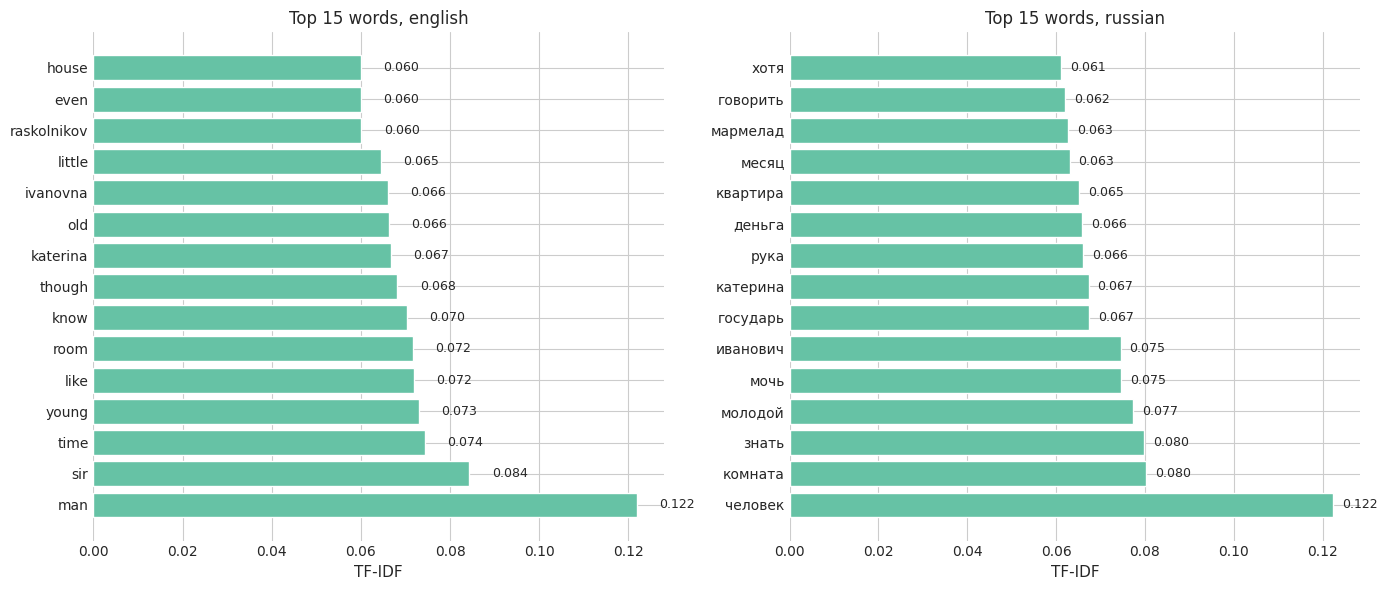

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
top_words_en = [feature_names_en[i] for i in top_20_idx_en[:15]]
top_scores_en = [tfidf_avg_en[i] for i in top_20_idx_en[:15]]
bars_en = axes[0].barh(top_words_en[::-1], top_scores_en[::-1])
axes[0].set_xlabel('TF-IDF', fontsize=11)
axes[0].set_title('Top 15 words, english', fontsize=12)
axes[0].invert_yaxis()

for bar, score in zip(bars_en, top_scores_en[::-1]):
    axes[0].text(score + 0.005, bar.get_y() + bar.get_height()/2, f'{score:.3f}',
                va='center', fontsize=9)

top_words_ru = [feature_names_ru[i] for i in top_20_idx_ru[:15]]
top_scores_ru = [tfidf_avg_ru[i] for i in top_20_idx_ru[:15]]
bars_ru = axes[1].barh(top_words_ru[::-1], top_scores_ru[::-1])
axes[1].set_xlabel('TF-IDF', fontsize=11)
axes[1].set_title('Top 15 words, russian', fontsize=12)
axes[1].invert_yaxis()

for bar, score in zip(bars_ru, top_scores_ru[::-1]):
    axes[1].text(score + 0.002, bar.get_y() + bar.get_height()/2, f'{score:.3f}',
                va='center', fontsize=9)

plt.tight_layout()
plt.savefig('tfidf_top_words_comparison.png', dpi=150, bbox_inches='tight')

In [84]:
svd_en = TruncatedSVD(n_components=10, random_state=42)
lsa_en = svd_en.fit_transform(tfidf_en)

print("\nExplained Variance (англ):")
for i, var in enumerate(svd_en.explained_variance_ratio_[:8], 1):
    print(f"Тема {i}: {var:.3f} ({var*100:.1f}%)")

components_en = svd_en.components_
print("\nТоп-12 слов по темам:")
for topic_idx in range(8):
    top_words_idx = components_en[topic_idx].argsort()[-12:][::-1]
    top_words = [feature_names_en[i] for i in top_words_idx]
    print(f"{topic_idx + 1}: {', '.join(top_words[:10])}")

svd_ru = TruncatedSVD(n_components=10, random_state=42)
lsa_ru = svd_ru.fit_transform(tfidf_ru)

print("\nExplained Variance (рус):")
for i, var in enumerate(svd_ru.explained_variance_ratio_[:8], 1):
    print(f"Тема {i}: {var:.3f} ({var*100:.1f}%)")

components_ru = svd_ru.components_
print("\nТоп-12 слов по темам:")
for topic_idx in range(8):
    top_words_idx = components_ru[topic_idx].argsort()[-12:][::-1]
    top_words = [feature_names_ru[i] for i in top_words_idx]
    print(f"{topic_idx + 1}: {', '.join(top_words[:10])}")


Explained Variance (англ):
Тема 1: 0.006 (0.6%)
Тема 2: 0.103 (10.3%)
Тема 3: 0.080 (8.0%)
Тема 4: 0.071 (7.1%)
Тема 5: 0.062 (6.2%)
Тема 6: 0.060 (6.0%)
Тема 7: 0.055 (5.5%)
Тема 8: 0.052 (5.2%)

Топ-12 слов по темам:
1: man, sir, know, room, time, katerina, ivanovna, young, like, though
2: old, woman, door, good, looked, like, eye, two, young, something
3: year, wife, dostoevsky, street, upon, man, feeling, suddenly, left, time
4: man, street, know, yes, go, young, landlady, katerina, sonia, matter
5: dostoevsky, year, katerina, work, room, ivanovna, time, sonia, house, hair
6: dostoevsky, landlady, rouble, nothing, two, year, hear, get, made, young
7: house, year, matter, go, going, step, upon, give, people, street
8: drink, education, woman, old, know, feeling, young, yet, man, sir

Explained Variance (рус):
Тема 1: 0.006 (0.6%)
Тема 2: 0.100 (10.0%)
Тема 3: 0.083 (8.3%)
Тема 4: 0.077 (7.7%)
Тема 5: 0.072 (7.2%)
Тема 6: 0.057 (5.7%)
Тема 7: 0.053 (5.3%)
Тема 8: 0.051 (5.1%)

Топ-1

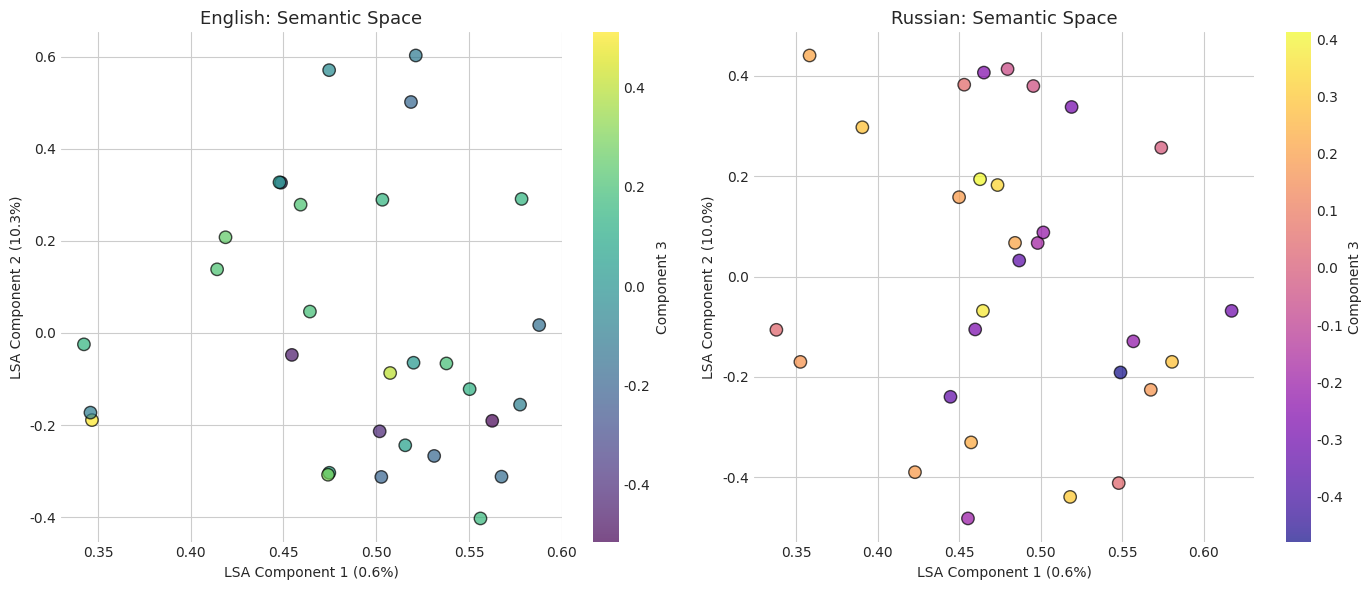

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

scatter_en = axes[0].scatter(lsa_en[:, 0], lsa_en[:, 1], c=lsa_en[:, 2],
                              cmap='viridis', s=80, alpha=0.7, edgecolors='black')
axes[0].set_xlabel(f'LSA Component 1 ({svd_en.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'LSA Component 2 ({svd_en.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title('English: Semantic Space', fontsize=13)
plt.colorbar(scatter_en, ax=axes[0], label='Component 3')

scatter_ru = axes[1].scatter(lsa_ru[:, 0], lsa_ru[:, 1], c=lsa_ru[:, 2],
                              cmap='plasma', s=80, alpha=0.7, edgecolors='black')
axes[1].set_xlabel(f'LSA Component 1 ({svd_ru.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'LSA Component 2 ({svd_ru.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].set_title('Russian: Semantic Space', fontsize=13)
plt.colorbar(scatter_ru, ax=axes[1], label='Component 3')

plt.tight_layout()
plt.savefig('lsa_semantic_space.png', dpi=150, bbox_inches='tight')

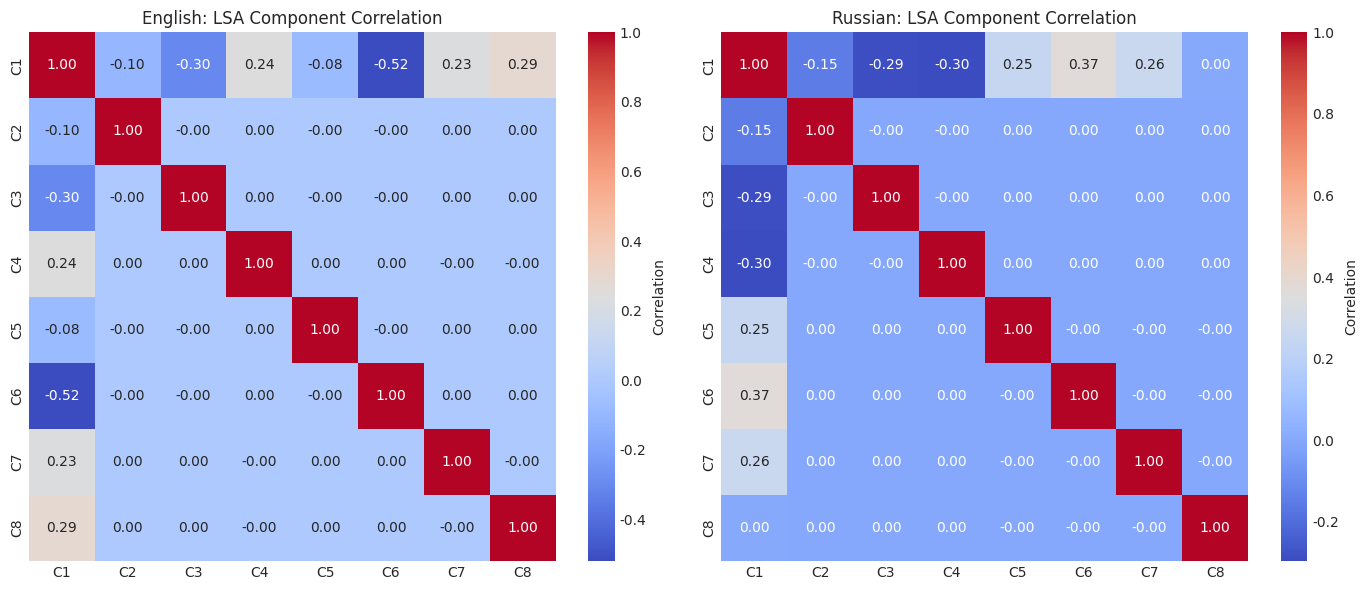

In [85]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

corr_en = np.corrcoef(lsa_en.T)
sns.heatmap(corr_en[:8, :8], annot=True, fmt='.2f', cmap='coolwarm',
            xticklabels=[f'C{i+1}' for i in range(8)],
            yticklabels=[f'C{i+1}' for i in range(8)],
            ax=axes[0], cbar_kws={'label': 'Correlation'})
axes[0].set_title('English: LSA Component Correlation', fontsize=12)

corr_ru = np.corrcoef(lsa_ru.T)
sns.heatmap(corr_ru[:8, :8], annot=True, fmt='.2f', cmap='coolwarm',
            xticklabels=[f'C{i+1}' for i in range(8)],
            yticklabels=[f'C{i+1}' for i in range(8)],
            ax=axes[1], cbar_kws={'label': 'Correlation'})
axes[1].set_title('Russian: LSA Component Correlation', fontsize=12)

plt.tight_layout()
plt.savefig('lsa_correlation_heatmap.png', dpi=150, bbox_inches='tight')


In [87]:
characters_ru = {
    'Раскольников': len(re.findall(r'раскольников|раскольникова|раскольникову|родя|родион', russian_text.lower())),
    'Соня': len(re.findall(r'соня|сонечка|софья', russian_text.lower())),
    'Разумихин': len(re.findall(r'разумихин|дмитрий', russian_text.lower())),
    'Порфирий': len(re.findall(r'порфирий', russian_text.lower())),
    'Лужин': len(re.findall(r'лужин', russian_text.lower())),
    'Мармеладов': len(re.findall(r'мармеладов', russian_text.lower())),
    'Дуня': len(re.findall(r'дуня|дунечка|авдотья', russian_text.lower()))
}

characters_en = {
    'Raskolnikov': len(re.findall(r'raskolnikov|rodion', english_text.lower())),
    'Sonia': len(re.findall(r'sonia|sonya|sofya', english_text.lower())),
    'Razumihin': len(re.findall(r'razumihin|dmitri', english_text.lower())),
    'Porfiry': len(re.findall(r'porfiry', english_text.lower())),
    'Luzhin': len(re.findall(r'luzhin', english_text.lower())),
    'Marmeladov': len(re.findall(r'marmeladov', english_text.lower())),
    'Dounia': len(re.findall(r'dounia|dunya|avdotya', english_text.lower()))
}

print("\nУпоминания персонажей (рус):")
for char, count in sorted(characters_ru.items(), key=lambda x: x[1], reverse=True):
    print(f"{char:15} : {count:5} раз")

print("\nУпоминания персонажей (англ):")
for char, count in sorted(characters_en.items(), key=lambda x: x[1], reverse=True):
    print(f"{char:15} : {count:5} раз")


Упоминания персонажей (рус):
Раскольников    :   978 раз
Разумихин       :   379 раз
Соня            :   322 раз
Дуня            :   290 раз
Порфирий        :   134 раз
Лужин           :   115 раз
Мармеладов      :    41 раз

Упоминания персонажей (англ):
Raskolnikov     :   883 раз
Sonia           :   478 раз
Dounia          :   440 раз
Razumihin       :   399 раз
Porfiry         :   206 раз
Luzhin          :   113 раз
Marmeladov      :    42 раз
